# Chapter 10 Trace: Spectral Data Exploration

`SpectralAnalysisPractice/SpeAna10_1-9_practicaluse.ipynb` の実行内容を、手元の `data/train.csv` / `data/test.csv` に合わせてトレースする notebook です。

教材第10章の対応:

- 10.1 スペクトルデータの読み込み
- 10.2 箱ひげ図による目的変数の分布の把握
- 10.3 スペクトル表示
- 10.4 ピーク検出
- 10.5 相関スペクトル
- 10.6 ベースライン補正
- 10.7 カーブフィッティング
- 10.8 ヒートマップによるスペクトル表示

このデータでは、横軸は波長ではなく波数 `cm^-1` として扱います。

## このノートでの樹種の扱い

このプロジェクトでは、樹種名・樹種番号はモデル構築の入力特徴量として使いません。未知サンプルでは樹種が不明な場合もありうるため、基本方針は「スペクトルだけから含水率を推定する樹種非依存モデル」です。

この探索ノートで樹種別に表示する場面がある場合も、それはデータ確認・異常値確認・結果解釈のための診断メタデータとして扱います。樹種ごとにモデルを分ける、樹種分類器を前段に置く、樹種名でモデル選択する、という方針は取りません。


## ライブラリをまとめてインポート

教材第10章の最初のインポートセルに対応します。日本語列名・樹種名を図に出すため、matplotlib の日本語フォントもここで設定します。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import ListedColormap
import seaborn as sns

from scipy import signal
from scipy.optimize import curve_fit
from scipy.special import wofz
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="notebook")

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Hiragino Sans", "AppleGothic", "Apple SD Gothic Neo", "Yu Gothic", "Meiryo", "Noto Sans CJK JP"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        print(f"Matplotlib font: {font_name}")
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("../data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMIT_PATH = DATA_DIR / "sample_submit.csv"

ENCODING = "cp932"
ID_COLS = ["sample number", "species number", "樹種"]
TARGET_COL = "含水率"

Matplotlib font: Hiragino Sans


## 10.1 スペクトルデータの読み込み

### コード10.1 CSVファイルの読み込み

教材では `spectra.csv` と `prop.csv` を分けて読み込んでいました。今回の `train.csv` は、ID列・目的変数・スペクトル列が1つの表にまとまっています。教材の `spectra` と `prop` に相当する形へ分解します。

In [2]:
train = pd.read_csv(TRAIN_PATH, encoding=ENCODING)
test = pd.read_csv(TEST_PATH, encoding=ENCODING)
sample_submit = pd.read_csv(SAMPLE_SUBMIT_PATH) if SAMPLE_SUBMIT_PATH.exists() else None

spectral_cols = [c for c in train.columns if c not in ID_COLS + [TARGET_COL]]
wave = np.array([float(c) for c in spectral_cols])

spectra = train[spectral_cols].astype(float)
test_spectra = test[spectral_cols].astype(float)
prop = train[["sample number", "species number", "樹種", TARGET_COL]].copy()
prop = prop.rename(columns={TARGET_COL: "mc"})

print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"spectra: {spectra.shape}")
print(f"test_spectra: {test_spectra.shape}")
print(f"wave range: {wave.max():.2f} - {wave.min():.2f} cm^-1")
print(f"wave points: {len(wave)}")

display(train.head())
display(prop.head())

train: (1322, 1559)
test : (550, 1558)
spectra: (1322, 1555)
test_spectra: (550, 1555)
wave range: 9993.77 - 3999.82 cm^-1
wave points: 1555


,sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,...,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139
0,1,1,イチョウ,216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.41470,...,1.25104,1.24925,1.24145,1.23620,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219
1,2,1,イチョウ,210.752688,0.42049,0.42040,0.42049,0.42053,0.42038,0.42010,...,1.21929,1.21611,1.21565,1.21745,1.21680,1.21205,1.21074,1.21508,1.21901,1.21846
2,3,1,イチョウ,205.913979,0.41040,0.41045,0.41047,0.41028,0.41000,0.40989,...,1.17471,1.17147,1.16611,1.16633,1.16998,1.16955,1.16200,1.15341,1.15139,1.15403
3,4,1,イチョウ,201.075269,0.40080,0.40061,0.40031,0.40008,0.39993,0.39991,...,1.11271,1.11339,1.11115,1.10965,1.11017,1.11165,1.11426,1.11787,1.11849,1.11328
4,5,1,イチョウ,196.236559,0.38792,0.38814,0.38825,0.38817,0.38798,0.38778,...,1.05617,1.05596,1.05760,1.06014,1.06240,1.06566,1.06962,1.07056,1.06459,1.05612


,sample number,species number,樹種,mc
0,1,1,イチョウ,216.129032
1,2,1,イチョウ,210.752688
2,3,1,イチョウ,205.913979
3,4,1,イチョウ,201.075269
4,5,1,イチョウ,196.236559


### コード10.2 データフレームへのラベルの追加とデータの概要の確認

教材では `Aga` / `Kiri` の2値ラベルを追加していました。今回のデータでは樹種情報を診断用メタデータとして保持しますが、モデル入力には使いません。

In [3]:
prop["label"] = prop["species number"].astype(int)

summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "samples": [len(train), len(test)],
    "total_columns": [train.shape[1], test.shape[1]],
    "spectral_columns": [spectra.shape[1], test_spectra.shape[1]],
    "missing_values": [train.isna().sum().sum(), test.isna().sum().sum()],
})

display(summary)
display(prop[["sample number", "species number", "樹種", "mc", "label"]].head())
display(prop["樹種"].value_counts().to_frame("count"))

,dataset,samples,total_columns,spectral_columns,missing_values
0,train,1322,1559,1555,0
1,test,550,1558,1555,0


,sample number,species number,樹種,mc,label
0,1,1,イチョウ,216.129032,1
1,2,1,イチョウ,210.752688,1
2,3,1,イチョウ,205.913979,1
3,4,1,イチョウ,201.075269,1
4,5,1,イチョウ,196.236559,1


,count
樹種,
トチ,183
ヒノキ,141
ベイスギ,112
ウォールナット,110
ナラ,107
スプルース,97
イチョウ,94
ベイマツ,93
クリ,91


## 10.2 箱ひげ図による目的変数の分布の把握

教材の `plot_boxplot_and_histogram` を、今回の `含水率` に対して実行します。主に全体分布を確認し、樹種別表示は診断用の補助確認として扱います。

In [4]:
def plot_boxplot_and_histogram(prop_data, bins=10, title="Property distribution"):
    prop_data = pd.Series(prop_data).dropna().astype(float)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    boxplot_dict = axes[0].boxplot(prop_data, whis=1.5, patch_artist=True)
    axes[0].set_title("Boxplot")
    axes[0].set_ylabel("Value")

    axes[1].hist(prop_data, bins=bins, color="steelblue", alpha=0.75)
    axes[1].set_title("Histogram")
    axes[1].set_xlabel("Value")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    Q1 = np.percentile(prop_data, 25)
    Q3 = np.percentile(prop_data, 75)
    IQR = Q3 - Q1
    whiskers = [item.get_ydata() for item in boxplot_dict["whiskers"]]
    lower_whisker = whiskers[0][1]
    upper_whisker = whiskers[1][1]
    fliers = [item.get_ydata() for item in boxplot_dict["fliers"]]
    outliers = fliers[0] if fliers else []

    print(f"Q1 (第一四分位数): {Q1:.2f}")
    print(f"Q3 (第三四分位数): {Q3:.2f}")
    print(f"IQR (四分位範囲): {IQR:.2f}")
    print(f"最小: {lower_whisker:.2f}")
    print(f"最大: {upper_whisker:.2f}")
    print(f"外れ値数: {len(outliers)}")
    print(f"外れ値: {np.round(outliers, 2)}")

### コード10.4 関数 plot_boxplot_and_histogram の実行

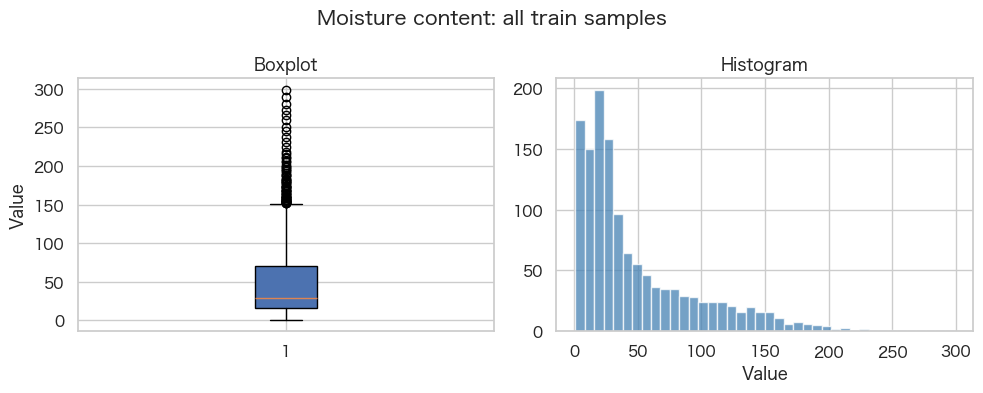

Q1 (第一四分位数): 16.11
Q3 (第三四分位数): 70.26
IQR (四分位範囲): 54.15
最小: 0.84
最大: 150.83
外れ値数: 71
外れ値: [216.13 210.75 205.91 201.08 196.24 191.4  186.56 182.26 177.42 173.12
 168.28 163.98 159.68 155.91 151.61 156.25 180.36 175.89 171.43 167.41
 163.84 159.82 156.25 152.68 160.08 152.94 158.92 155.6  152.7  153.82
 198.54 193.69 187.86 182.52 177.67 172.82 167.48 163.11 158.74 153.88
 298.58 288.65 280.85 273.05 265.96 258.87 251.06 244.68 237.59 231.21
 224.82 217.73 212.06 205.67 199.29 194.33 188.65 183.69 178.72 173.76
 169.5  164.54 160.28 156.03 151.77 180.54 173.3  167.87 161.54 156.56
 152.04]


,count,mean,std,min,median,max
樹種,,,,,,
ヒノキ,141,39.609585,53.227156,0.970874,7.281553,198.543689
ウエンジ,87,15.461847,12.395327,4.216867,10.843373,58.734940
スプルース,97,37.074417,42.848894,0.840336,15.546218,160.084034
トチ,183,31.619374,29.253417,13.253012,20.080321,153.815261
ホワイトオーク,51,33.413133,20.168839,12.209302,26.453488,84.883721
チェリー,88,53.380800,49.720184,4.149378,28.423237,158.921162
ベイマツ,93,41.831939,38.281756,2.592593,28.518519,138.888889
ナラ,107,41.790332,25.678688,16.932907,32.587859,114.057508
ウォールナット,110,57.219697,36.561529,24.166667,40.625000,156.250000


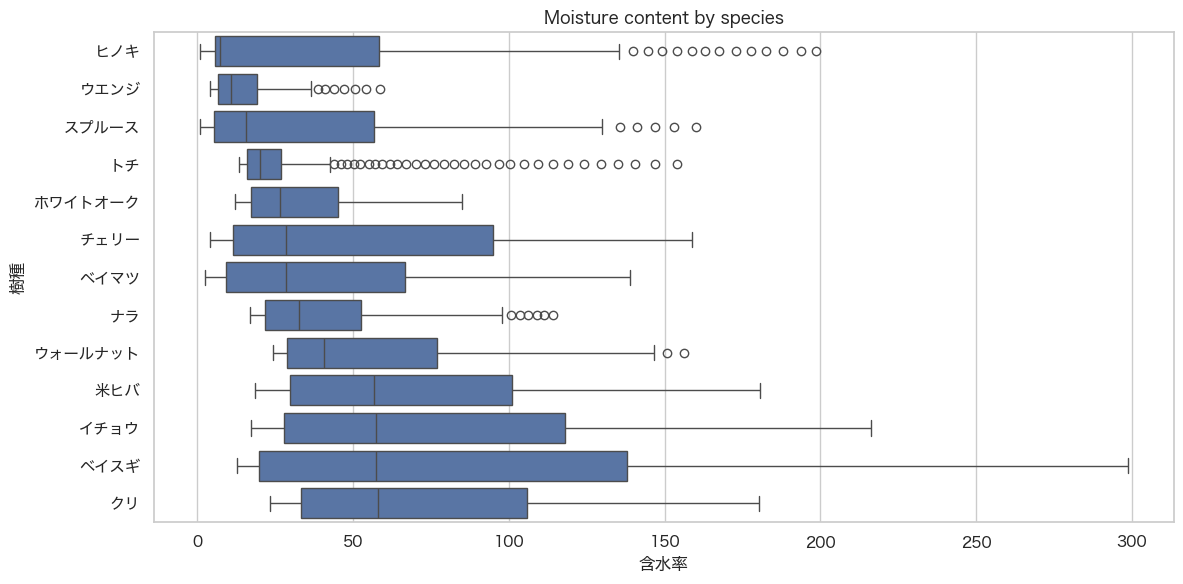

In [5]:
plot_boxplot_and_histogram(prop["mc"], bins=40, title="Moisture content: all train samples")

display(prop.groupby("樹種")["mc"].agg(["count", "mean", "std", "min", "median", "max"]).sort_values("median"))

plt.figure(figsize=(12, 6))
order = prop.groupby("樹種")["mc"].median().sort_values().index
sns.boxplot(data=prop, y="樹種", x="mc", order=order)
plt.title("Moisture content by species")
plt.xlabel("含水率")
plt.ylabel("樹種")
plt.tight_layout()

## 10.3 スペクトル表示

教材の `plot_spectra` に対応します。今回の横軸は波数なので、高波数から低波数へ見えるように反転します。

In [6]:
def plot_spectra(wave, spec, title="Spectra", n_samples=None, color_by=None):
    spec_df = pd.DataFrame(spec).copy()
    if n_samples is not None and n_samples < len(spec_df):
        idx = np.linspace(0, len(spec_df) - 1, n_samples).astype(int)
        spec_df = spec_df.iloc[idx]
        color_by = None if color_by is None else pd.Series(color_by).iloc[idx]

    fig, ax = plt.subplots(figsize=(14, 6))
    if color_by is None:
        ax.plot(wave, spec_df.T, alpha=0.25, linewidth=0.8)
    else:
        color_by = pd.Series(color_by, index=spec_df.index)
        palette = dict(zip(sorted(color_by.unique()), sns.color_palette("tab20", color_by.nunique())))
        for label, group_idx in color_by.groupby(color_by).groups.items():
            group = spec_df.loc[group_idx]
            color = palette[label]
            ax.plot(wave, group.T, color=color, alpha=0.10, linewidth=0.7)
            ax.plot(wave, group.mean(axis=0), color=color, linewidth=2.0, label=label)
        ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
        fig.subplots_adjust(right=0.78)

    ax.invert_xaxis()
    ax.set_xlabel("Wavenumber (cm^-1)")
    ax.set_ylabel("Absorbance / intensity")
    ax.set_title(title)
    plt.show()

### コード10.6 関数 plot_spectra の実行

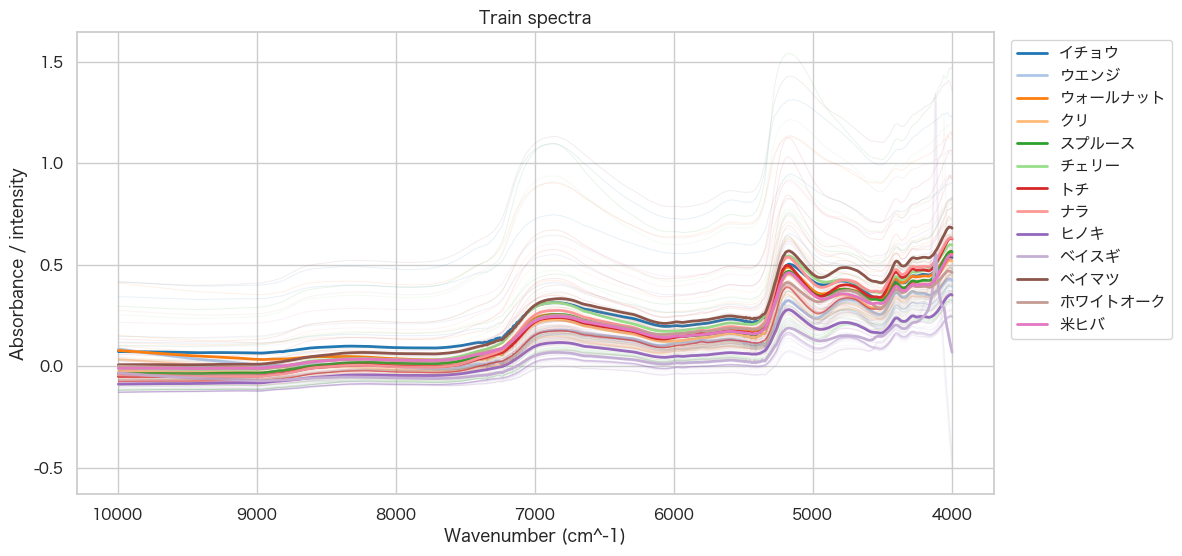

/var/folders/xv/t5d10dz50qvcnsq5cx2x9bbh0000gn/T/ipykernel_63134/3073545226.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mean_by_species = spectra.assign(樹種=prop["樹種"].values).groupby("樹種").mean()


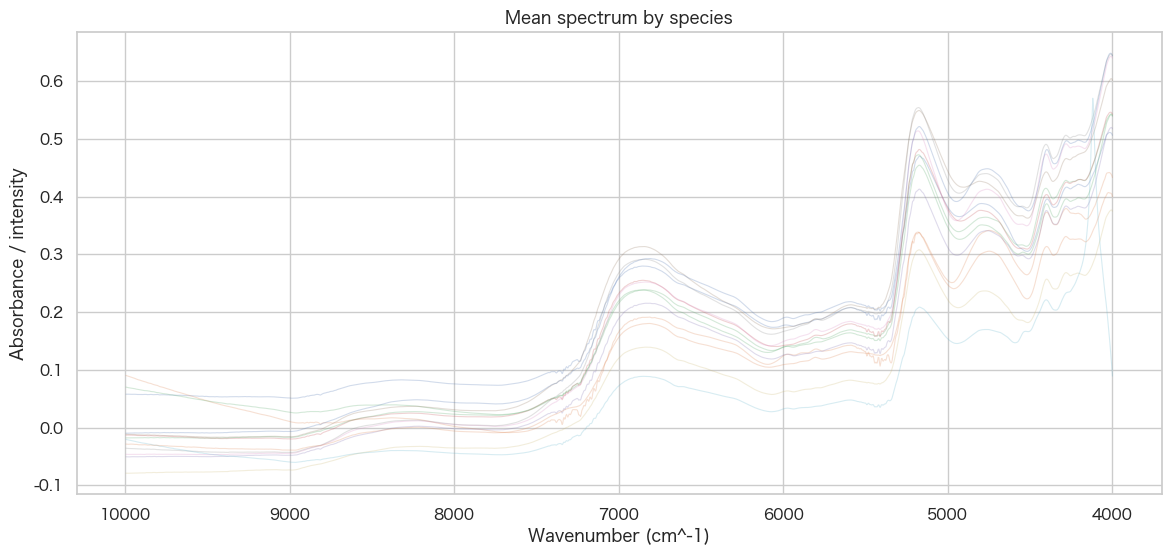

In [7]:
plot_spectra(wave, spectra, title="Train spectra", n_samples=160, color_by=prop["樹種"])

mean_by_species = spectra.assign(樹種=prop["樹種"].values).groupby("樹種").mean()
plot_spectra(wave, mean_by_species, title="Mean spectrum by species")

## 10.4 ピーク検出

教材の `detect_peaks` に対応します。生スペクトルの正ピークと、Savitzky-Golay 2次微分スペクトルの負ピークを検出します。

In [8]:
def _as_odd_window(num_smooth, n_points):
    num_smooth = int(num_smooth)
    if num_smooth % 2 == 0:
        num_smooth += 1
    return min(num_smooth, n_points - 1 if (n_points - 1) % 2 == 1 else n_points - 2)


def detect_peaks(wave, spec, num_smooth, max_labels=25):
    spec_array = spec.values if hasattr(spec, "values") else np.asarray(spec)
    spec_array = np.asarray(spec_array, dtype=float).ravel()
    wave_array = np.asarray(wave, dtype=float)
    num_smooth = _as_odd_window(num_smooth, len(spec_array))

    derispec_array = signal.savgol_filter(spec_array, num_smooth, 2, 2)
    spec_peaks_posi, _ = signal.find_peaks(spec_array)
    derispec_peaks_posi, _ = signal.find_peaks(-derispec_array)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    axes[0].plot(wave_array, spec_array, color="teal", label="Spectra")
    axes[0].plot(wave_array[spec_peaks_posi], spec_array[spec_peaks_posi], "o", markersize=4, label="Positive Peaks")
    top_spec = spec_peaks_posi[np.argsort(spec_array[spec_peaks_posi])[-max_labels:]] if len(spec_peaks_posi) else []
    for pos in top_spec:
        axes[0].text(wave_array[pos], spec_array[pos], f"{wave_array[pos]:.0f}", fontsize=8, va="bottom")
    axes[0].set_title("Spectra and Positive Peaks")
    axes[0].set_ylabel("Intensity")
    axes[0].legend()

    axes[1].plot(wave_array, derispec_array, color="teal", label="2nd derivative")
    axes[1].plot(wave_array[derispec_peaks_posi], derispec_array[derispec_peaks_posi], "o", markersize=4, label="Negative Peaks")
    top_deri = derispec_peaks_posi[np.argsort(-derispec_array[derispec_peaks_posi])[-max_labels:]] if len(derispec_peaks_posi) else []
    for pos in top_deri:
        axes[1].text(wave_array[pos], derispec_array[pos], f"{wave_array[pos]:.0f}", fontsize=8, va="bottom")
    axes[1].set_title("2nd derivative and Negative Peaks")
    axes[1].set_xlabel("Wavenumber (cm^-1)")
    axes[1].set_ylabel("2nd derivative")
    axes[1].legend()

    for ax in axes:
        ax.invert_xaxis()
    plt.tight_layout()
    plt.show()

    return {
        "raw_peak_positions": wave_array[spec_peaks_posi],
        "derivative_negative_peak_positions": wave_array[derispec_peaks_posi],
        "derivative": derispec_array,
    }

### コード10.8 関数 detect_peaks の実行

まず、含水率が中央値に近い代表サンプルで確認します。

representative sample


,sample number,species number,樹種,mc,label
811,1309,13,ナラ,29.073482,13


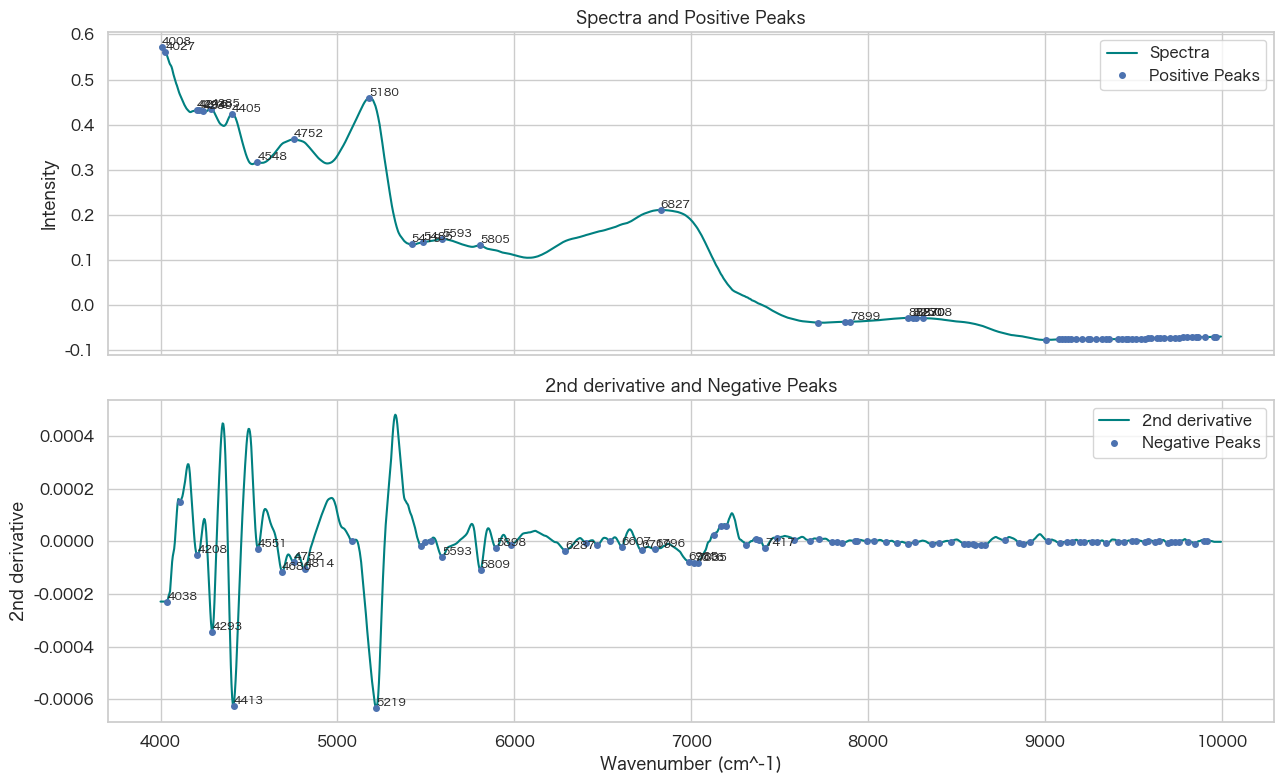

In [9]:
representative_idx = (prop["mc"] - prop["mc"].median()).abs().idxmin()
print("representative sample")
display(prop.loc[[representative_idx]])

peak_result = detect_peaks(wave, spectra.loc[representative_idx], num_smooth=21, max_labels=20)

## 10.5 相関スペクトル

教材の `plot_correlation_spectrum` に対応します。生スペクトルと2次微分スペクトルそれぞれについて、含水率との相関を確認します。

In [10]:
def plot_correlation_spectrum(wave, spec, num_smooth, propdata):
    spec_df = pd.DataFrame(spec).astype(float)
    wave_array = np.asarray(wave, dtype=float)
    prop_array = np.asarray(propdata, dtype=float)
    num_smooth = _as_odd_window(num_smooth, spec_df.shape[1])

    derispec = signal.savgol_filter(spec_df.values, num_smooth, 2, 2, axis=1)
    spec_corr = np.array([np.corrcoef(spec_df.iloc[:, i], prop_array)[0, 1] for i in range(spec_df.shape[1])])
    derispec_corr = np.array([np.corrcoef(derispec[:, i], prop_array)[0, 1] for i in range(derispec.shape[1])])

    fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
    axes[0].plot(wave_array, spec_df.T, alpha=0.08, linewidth=0.7)
    axes[0].set_title("Spectra")
    axes[0].set_ylabel("Intensity")

    axes[1].plot(wave_array, spec_corr, color="black")
    axes[1].set_title("Correlation Spectrum for Spectra")
    axes[1].set_ylabel("Correlation")
    axes[1].set_ylim(-1, 1)
    axes[1].axhline(0, color="gray", linewidth=0.8)

    axes[2].plot(wave_array, derispec.T, alpha=0.08, linewidth=0.7)
    axes[2].set_title("2nd derivative spectra")
    axes[2].set_ylabel("2nd derivative")

    axes[3].plot(wave_array, derispec_corr, color="black")
    axes[3].set_title("Correlation Spectrum for 2nd derivative spectra")
    axes[3].set_xlabel("Wavenumber (cm^-1)")
    axes[3].set_ylabel("Correlation")
    axes[3].set_ylim(-1, 1)
    axes[3].axhline(0, color="gray", linewidth=0.8)

    for ax in axes:
        ax.invert_xaxis()
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        "wavenumber": wave_array,
        "raw_corr": spec_corr,
        "derivative_corr": derispec_corr,
    })

### コード10.10 関数 plot_correlation_spectrum の実行

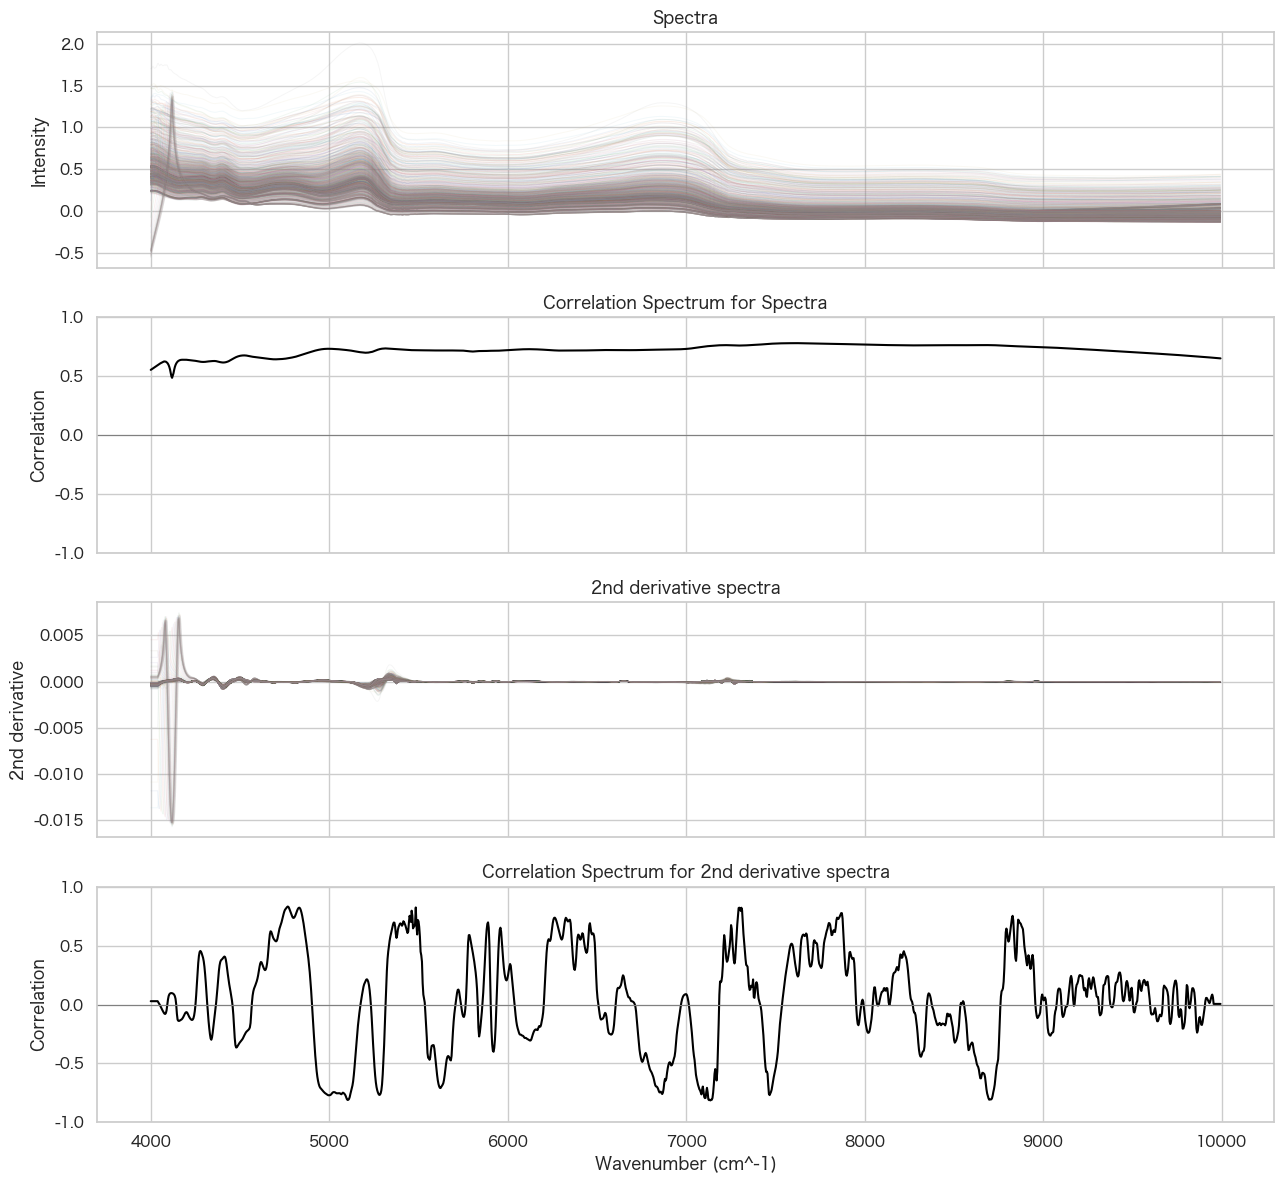

,wavenumber,raw_corr,derivative_corr,abs_raw_corr,abs_derivative_corr
1355,4767.38596,0.650185,0.832027,0.650185,0.832027
1354,4771.24306,0.651220,0.829225,0.651220,0.829225
1356,4763.52885,0.649240,0.827429,0.649240,0.827429
1169,5484.80811,0.718895,0.824268,0.718895,0.824268
699,7297.64905,0.758812,0.822470,0.758812,0.822470
1338,4832.95680,0.673059,0.822201,0.673059,0.822201
696,7309.22038,0.758939,0.821949,0.758939,0.821949
1339,4829.09969,0.671261,0.821304,0.671261,0.821304
1357,4759.67174,0.648381,0.820180,0.648381,0.820180
700,7293.79194,0.758888,0.819101,0.758888,0.819101


In [11]:
corr_df = plot_correlation_spectrum(wave, spectra, 21, prop["mc"])

display(
    corr_df.assign(abs_raw_corr=lambda d: d["raw_corr"].abs(),
                   abs_derivative_corr=lambda d: d["derivative_corr"].abs())
    .sort_values("abs_derivative_corr", ascending=False)
    .head(20)
)

## 10.6 ベースライン補正

教材の `baseline_shift` に対応します。教材では固定波長 `1381`〜`1641` を使っていましたが、このデータは波数範囲が異なるため、相関スペクトルで強く反応した領域を中心に補正範囲を設定します。

初期値は含水率との相関が高かった 7600 cm^-1 近傍です。必要に応じて `BASELINE_WAVE_HIGH` / `BASELINE_WAVE_LOW` を変更してください。

In [12]:
def baseline_shift(wave, spec, wave1, wave2):
    wave_array = np.asarray(wave, dtype=float)
    spec_df = pd.DataFrame(spec).astype(float).copy()

    wave1_col = int(np.abs(wave_array - wave1).argmin())
    wave2_col = int(np.abs(wave_array - wave2).argmin())
    start_col, end_col = sorted([wave1_col, wave2_col])

    x1 = wave_array[start_col]
    x2 = wave_array[end_col]
    y1 = spec_df.iloc[:, start_col]
    y2 = spec_df.iloc[:, end_col]

    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1

    shifted_spec = spec_df.copy()
    selected_wave = wave_array[start_col:end_col + 1]
    baseline = np.outer(slope.values, selected_wave) + intercept.values[:, None]
    shifted_spec.iloc[:, start_col:end_col + 1] = spec_df.iloc[:, start_col:end_col + 1].values - baseline

    shifted_spec = shifted_spec.iloc[:, start_col:end_col + 1]
    shifted_wave = selected_wave
    integ_spec = shifted_spec.sum(axis=1)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    axes[0].plot(wave_array, spec_df.T, alpha=0.05, linewidth=0.7)
    axes[0].axvspan(min(shifted_wave), max(shifted_wave), color="orange", alpha=0.15)
    axes[0].set_title("Spectra")
    axes[0].set_ylabel("Intensity")

    axes[1].plot(shifted_wave, shifted_spec.T, alpha=0.08, linewidth=0.7)
    axes[1].set_title("Baseline-shifted spectra")
    axes[1].set_ylabel("Shifted intensity")

    axes[2].scatter(range(1, len(integ_spec) + 1), integ_spec, s=12, alpha=0.7)
    axes[2].set_title("Integrated shifted spectra")
    axes[2].set_xlabel("Sample number")
    axes[2].set_ylabel("Integrated intensity")

    for ax in axes[:2]:
        ax.invert_xaxis()
        ax.set_xlabel("Wavenumber (cm^-1)")
    plt.tight_layout()
    plt.show()

    return shifted_wave, shifted_spec, integ_spec

### コード10.12 関数 baseline_shift の実行

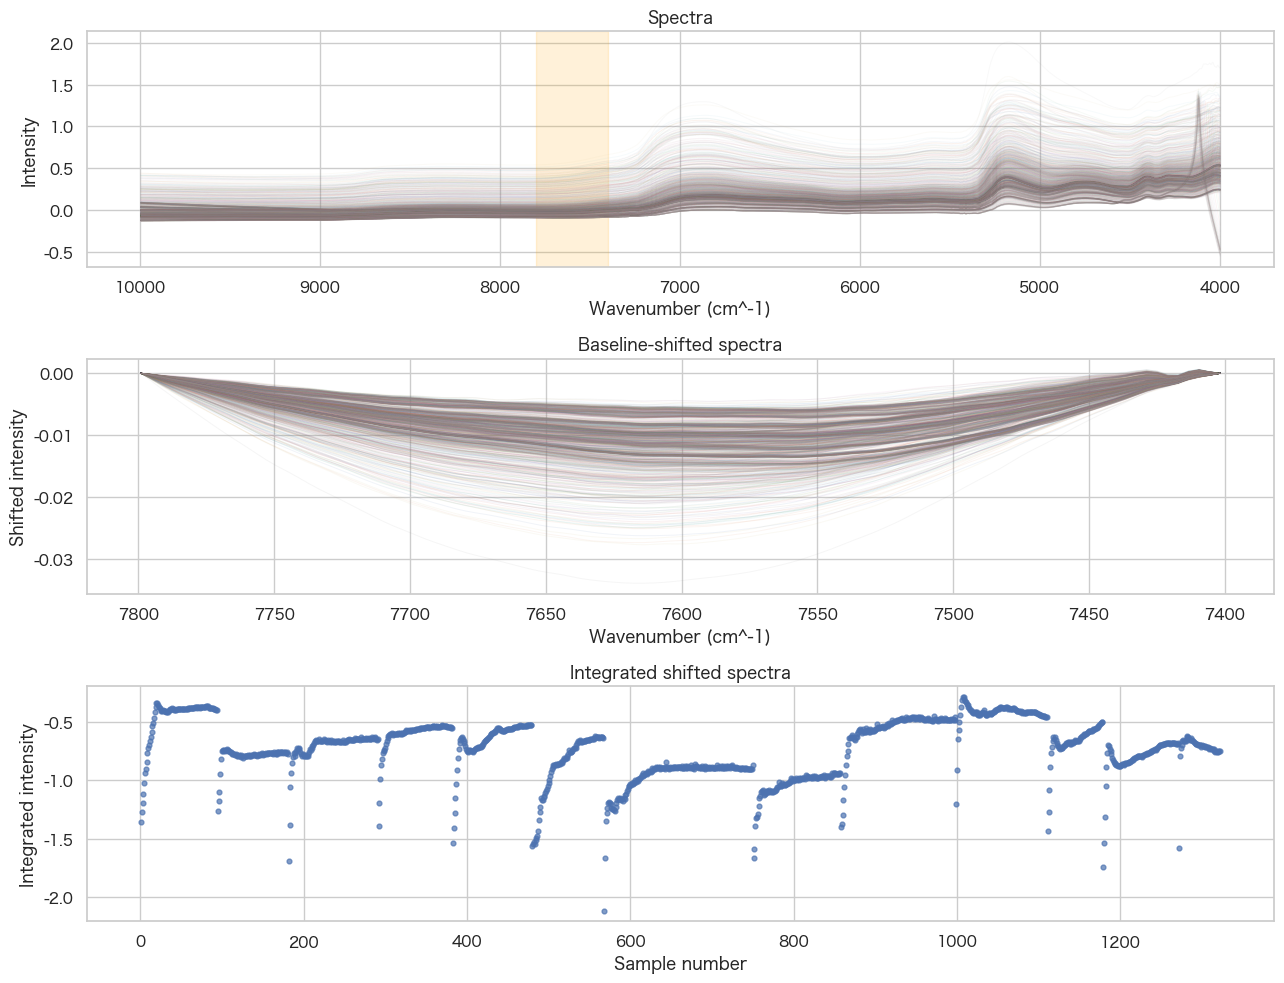

,sample number,樹種,mc,integrated_shifted_spectrum
0,1,イチョウ,216.129032,-1.35801
1,2,イチョウ,210.752688,-1.27524
2,3,イチョウ,205.913979,-1.19662
3,4,イチョウ,201.075269,-1.11413
4,5,イチョウ,196.236559,-1.02491


correlation with mc: -0.19677703194899993


In [13]:
BASELINE_WAVE_HIGH = 7800
BASELINE_WAVE_LOW = 7400

shifted_wave, shifted_spec, integ_spec = baseline_shift(spectra.columns.astype(float), spectra, BASELINE_WAVE_HIGH, BASELINE_WAVE_LOW)

integ_check = pd.DataFrame({
    "sample number": prop["sample number"],
    "樹種": prop["樹種"],
    "mc": prop["mc"],
    "integrated_shifted_spectrum": integ_spec,
})

display(integ_check.head())
print("correlation with mc:", integ_check["integrated_shifted_spectrum"].corr(integ_check["mc"]))

## 10.7 カーブフィッティング

教材と同様に、補正後スペクトルのピークを確認し、2つのフォークト関数でフィッティングします。

注意: 今回の train は 1322件あるため、初期値では一部サンプルのみ実行します。全件で実行したい場合は `FIT_SAMPLE_LIMIT = None` に変更してください。

### コード10.13 補正後のスペクトルのピーク位置

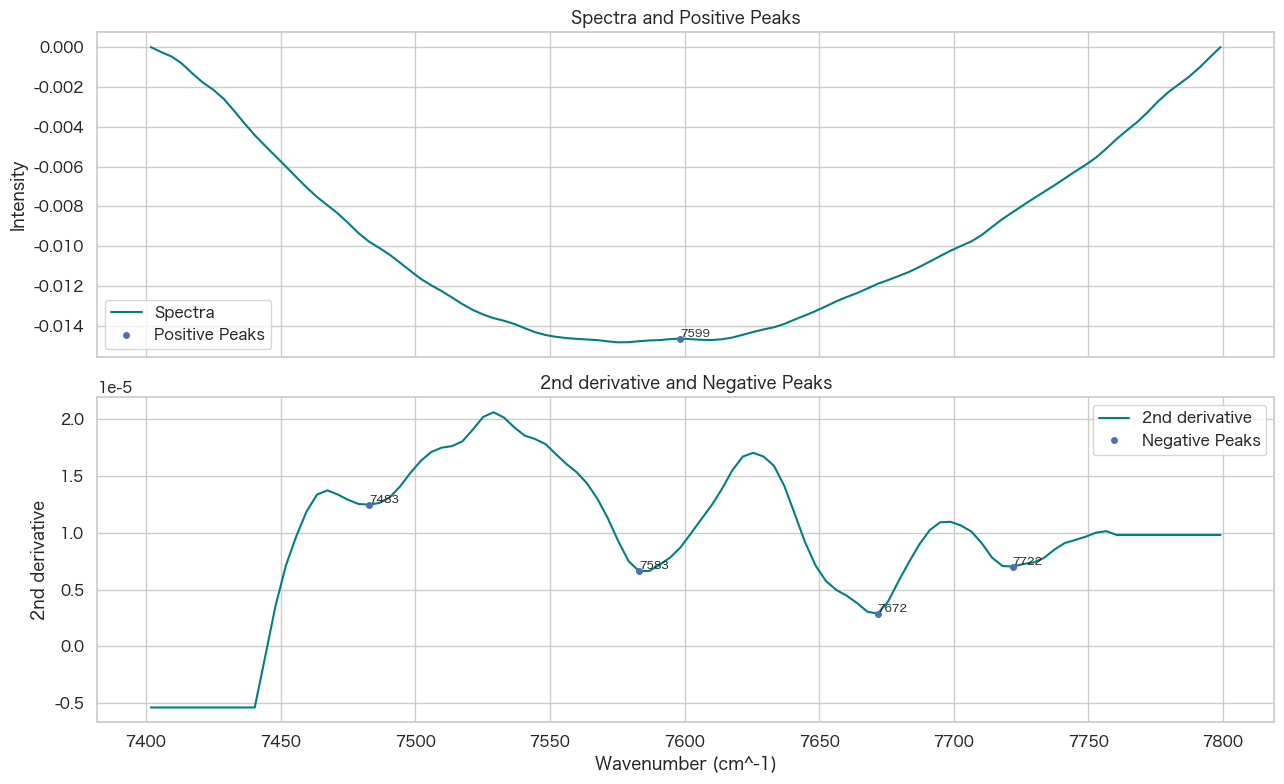

initial_peak_positions: [7471.21893, 7586.93218]


In [14]:
peak_shifted_result = detect_peaks(shifted_wave, shifted_spec.iloc[representative_idx], num_smooth=21, max_labels=20)

mean_shifted = shifted_spec.mean(axis=0).values
mean_derivative = signal.savgol_filter(mean_shifted, _as_odd_window(21, len(mean_shifted)), 2, 2)
neg_peaks, _ = signal.find_peaks(-mean_derivative)
if len(neg_peaks) >= 2:
    selected = neg_peaks[np.argsort(-mean_derivative[neg_peaks])[:2]]
    initial_peak_positions = sorted(shifted_wave[selected].astype(float).tolist())
else:
    initial_peak_positions = [float(np.percentile(shifted_wave, 35)), float(np.percentile(shifted_wave, 65))]

print("initial_peak_positions:", initial_peak_positions)

### コード10.14 フォークト関数によるカーブフィッティング

In [15]:
def voigt(x, amplitude, mean, sigma, gamma):
    z = ((x - mean) + 1j * gamma) / (sigma * np.sqrt(2))
    return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi))


def voigt_double(x, amp1, mean1, sigma1, gamma1, amp2, mean2, sigma2, gamma2):
    return voigt(x, amp1, mean1, sigma1, gamma1) + voigt(x, amp2, mean2, sigma2, gamma2)


def fit_voigt_double(wavelength, spec, initial_peak_positions):
    wavelength = np.asarray(wavelength, dtype=float)
    spec_array = np.asarray(spec, dtype=float)
    results = []
    failures = []

    fig, axes = plt.subplots(4, 2, figsize=(13, 12))
    axes = axes.ravel()

    lower_wave = float(np.min(wavelength))
    upper_wave = float(np.max(wavelength))

    for i, specs in enumerate(tqdm(spec_array, desc="Fitting progress")):
        try:
            max_index1 = int(np.argmin(np.abs(wavelength - initial_peak_positions[0])))
            max_index2 = int(np.argmin(np.abs(wavelength - initial_peak_positions[1])))
            amp1 = max(float(specs[max_index1]), 1e-8)
            amp2 = max(float(specs[max_index2]), 1e-8)
            initial_guess = [amp1, initial_peak_positions[0], 40, 5, amp2, initial_peak_positions[1], 40, 5]

            lower_bounds = [0, lower_wave, 1e-8, 1e-8, 0, lower_wave, 1e-8, 1e-8]
            upper_bounds = [np.inf, upper_wave, np.inf, np.inf, np.inf, upper_wave, np.inf, np.inf]

            popt, pcov = curve_fit(
                voigt_double,
                wavelength,
                specs,
                p0=initial_guess,
                bounds=(lower_bounds, upper_bounds),
                maxfev=20000,
            )
            perr = np.sqrt(np.diag(pcov))

            peak_position1 = popt[1]
            peak_position2 = popt[5]
            area1 = popt[0] * (np.sqrt(2 * np.pi) * np.abs(popt[2]) + 2 * np.abs(popt[3]))
            area2 = popt[4] * (np.sqrt(2 * np.pi) * np.abs(popt[6]) + 2 * np.abs(popt[7]))
            fwhm1 = 2 * np.sqrt(2 * np.log(2)) * (np.abs(popt[2]) + np.abs(popt[3]))
            fwhm2 = 2 * np.sqrt(2 * np.log(2)) * (np.abs(popt[6]) + np.abs(popt[7]))

            results.append((peak_position1, area1, fwhm1, peak_position2, area2, fwhm2, np.mean(perr)))

            if len(results) == 1:
                axes[0].plot(wavelength, specs, "k-", label="Original Spectrum")
                axes[0].plot(wavelength, voigt(wavelength, popt[0], popt[1], popt[2], popt[3]), "m--", label="Voigt Fit 1")
                axes[0].plot(wavelength, voigt(wavelength, popt[4], popt[5], popt[6], popt[7]), "c--", label="Voigt Fit 2")
                axes[0].plot(wavelength, voigt_double(wavelength, *popt), "r--", label="Double Voigt Fit")
                axes[0].invert_xaxis()
                axes[0].set_xlabel("Wavenumber (cm^-1)")
                axes[0].set_ylabel("Intensity")
                axes[0].legend()
        except Exception as exc:
            failures.append((i, str(exc)))
            results.append((np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan))

    result_df = pd.DataFrame(
        results,
        columns=["peak_position1", "area1", "fwhm1", "peak_position2", "area2", "fwhm2", "mean_error"],
    )

    sample_numbers = np.arange(1, len(result_df) + 1)
    plot_specs = [
        ("peak_position1", "m", "Peak Position 1"),
        ("peak_position2", "c", "Peak Position 2"),
        ("area1", "m", "Area 1"),
        ("area2", "c", "Area 2"),
        ("fwhm1", "m", "FWHM 1"),
        ("fwhm2", "c", "FWHM 2"),
        ("mean_error", "k", "Average Fitting Error"),
    ]
    for ax, (col, color, title) in zip(axes[1:], plot_specs):
        ax.scatter(sample_numbers, result_df[col], c=color, s=14)
        ax.set_xlabel("Sample Number")
        ax.set_ylabel(title)

    plt.tight_layout()
    plt.show()

    print(f"fit failures: {len(failures)} / {len(result_df)}")
    if failures[:5]:
        print("first failures:", failures[:5])
    return result_df

### コード10.15 関数 fit_results の実行

Fitting progress:   0%|          | 0/80 [00:00<?, ?it/s]

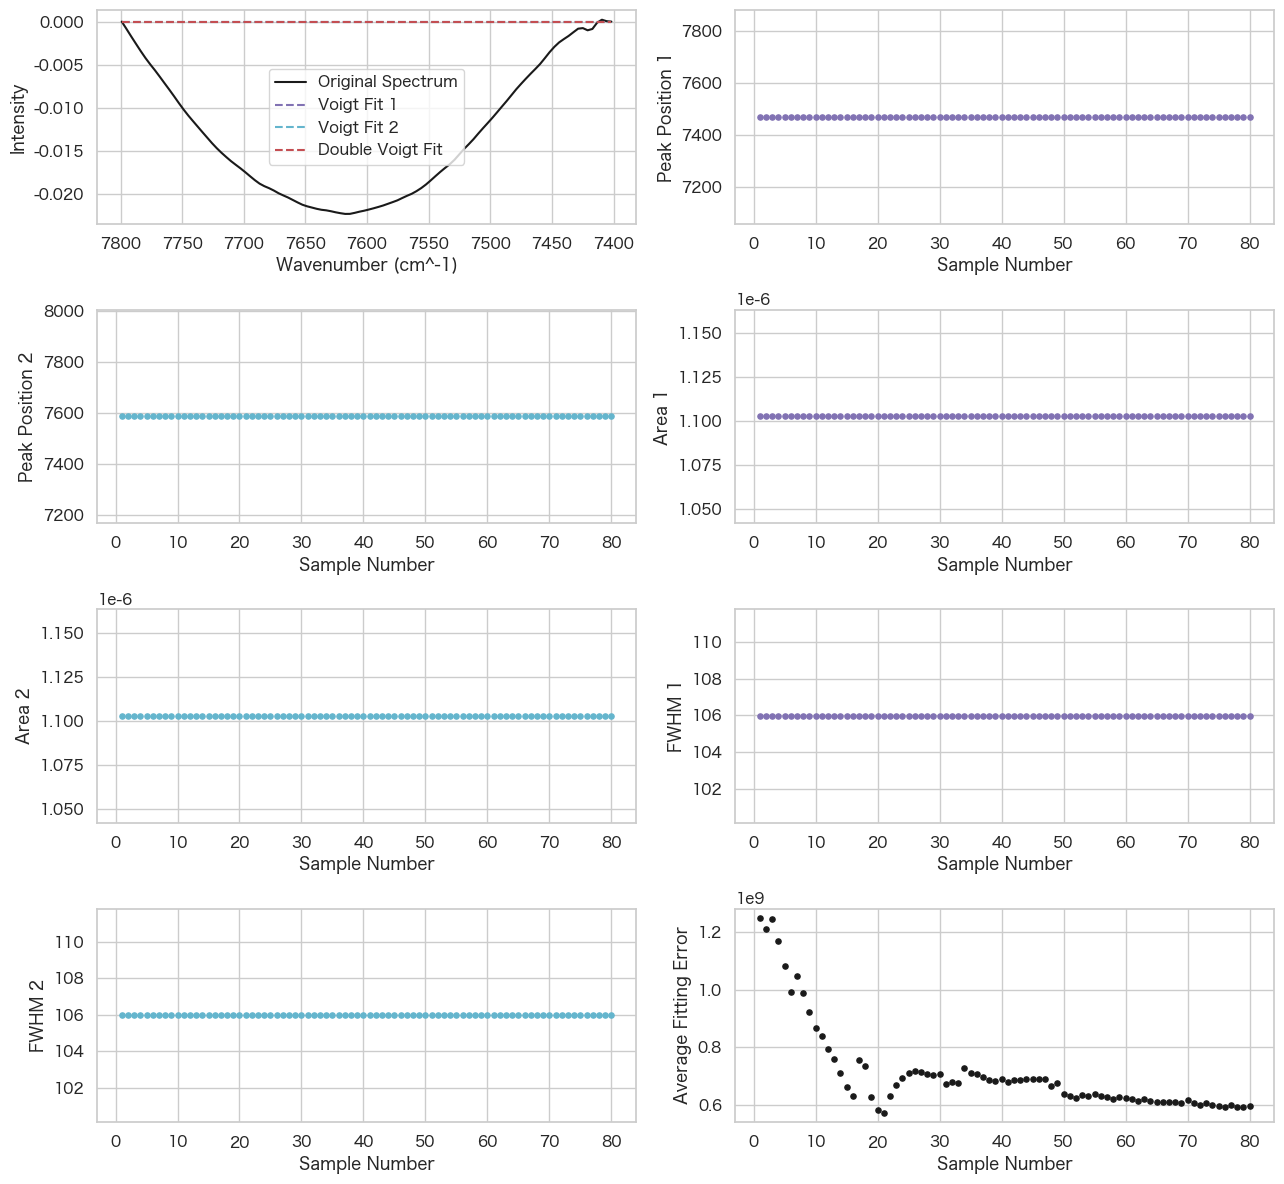

fit failures: 0 / 80


,sample number,species number,樹種,mc,label,peak_position1,area1,fwhm1,peak_position2,area2,fwhm2,mean_error
0,1,1,イチョウ,216.129032,1,7471.21893,0.000001,105.966902,7586.93218,0.000001,105.966902,1.247764e+09
1,2,1,イチョウ,210.752688,1,7471.21893,0.000001,105.966902,7586.93218,0.000001,105.966902,1.211743e+09
2,3,1,イチョウ,205.913979,1,7471.21893,0.000001,105.966902,7586.93218,0.000001,105.966902,1.243883e+09
3,4,1,イチョウ,201.075269,1,7471.21893,0.000001,105.966902,7586.93218,0.000001,105.966902,1.170315e+09
4,5,1,イチョウ,196.236559,1,7471.21893,0.000001,105.966902,7586.93218,0.000001,105.966902,1.081631e+09


,mc,area1,area2,fwhm1,fwhm2,mean_error
mc,1.0,NaN,NaN,NaN,NaN,0.812922


In [16]:
FIT_SAMPLE_LIMIT = 80  # 全件実行する場合は None に変更
fit_input = shifted_spec.values if FIT_SAMPLE_LIMIT is None else shifted_spec.iloc[:FIT_SAMPLE_LIMIT].values
fit_meta = prop if FIT_SAMPLE_LIMIT is None else prop.iloc[:FIT_SAMPLE_LIMIT].copy()

fit_results = fit_voigt_double(shifted_wave, fit_input, initial_peak_positions)
fit_results = pd.concat([fit_meta.reset_index(drop=True), fit_results], axis=1)
display(fit_results.head())

display(fit_results[["mc", "area1", "area2", "fwhm1", "fwhm2", "mean_error"]].corr(numeric_only=True).loc[["mc"]])

## 10.8 ヒートマップによるスペクトル表示

教材の `plot_spectra_heatmap` に対応します。最後に、主に評価に使いたい 2次微分スペクトルをヒートマップで確認します。

In [17]:
def plot_spectra_heatmap(wave, spec, vmin=None, vmax=None, title="Spectra heatmap"):
    spec_df = pd.DataFrame(spec)
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [1, 1.3]})

    axes[0].plot(wave, spec_df.T, alpha=0.08, linewidth=0.7)
    axes[0].invert_xaxis()
    axes[0].set_ylabel("spectra")
    axes[0].set_title(title)

    sns.heatmap(
        spec_df,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        yticklabels=False,
        xticklabels=False,
        cbar=True,
        cbar_kws={"label": "Value"},
        ax=axes[1],
    )
    axes[1].set_xlabel("Wavenumber")
    axes[1].set_ylabel("Sample")
    plt.tight_layout()
    plt.show()

### コード10.17 関数 plot_spectra_heatmap の実行

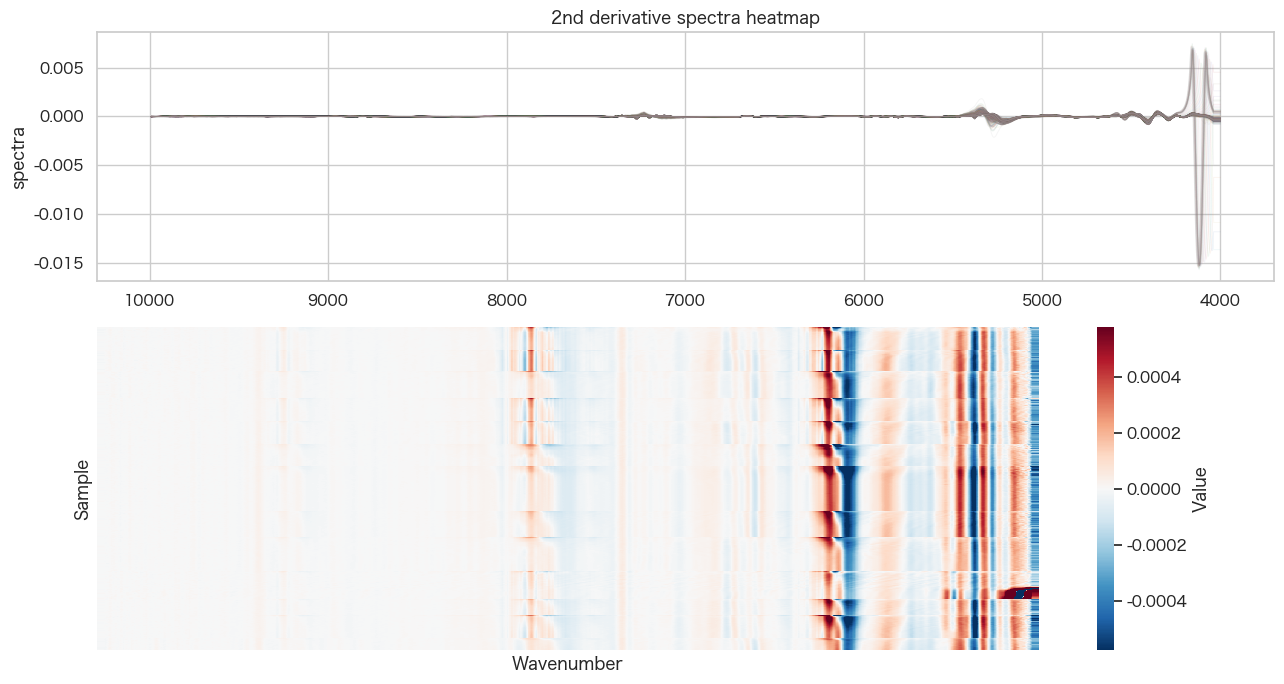

In [18]:
DERIV_WINDOW = 21
DERIV_POLYORDER = 2

derispec = signal.savgol_filter(spectra.values, DERIV_WINDOW, DERIV_POLYORDER, 2, axis=1)
derispec_df = pd.DataFrame(derispec, index=spectra.index, columns=spectra.columns)

q = np.nanquantile(np.abs(derispec), 0.995)
plot_spectra_heatmap(wave, derispec_df, vmin=-q, vmax=q, title="2nd derivative spectra heatmap")

## 第10章トレース後の確認ポイント

- 含水率は右に裾が長く、高含水率サンプルがモデル評価に強く効きます。
- 相関スペクトルでは、生スペクトルと2次微分スペクトルのどちらが含水率に反応するか比較できます。
- 今回の評価方針では、2次微分スペクトルを主軸にして `DERIV_WINDOW` を変えながら比較するのが自然です。
- フォークトフィットは探索的特徴量として扱い、まずは一部サンプルで安定性を確認してから全件に広げます。
- 次章相当のモデル評価では、樹種名を特徴量に使わないスペクトル単独モデルを基本にします。樹種情報は必要に応じて診断用にだけ使います。